# MetricTensor2D — Oblique lattice geometry and reciprocal space

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>

## Question

How does a constant metric generalize lengths, reciprocal vectors, and the Laplacian in an oblique cell?

## Learning objectives

- Construct direct, inverse, dual, and reciprocal metrics.
- Compute cell area, lengths, angles, and periodic distances.
- Identify mixed derivatives caused by an off-diagonal inverse metric.
- Recover the rectangular Cartesian limit.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This is the first non-orthogonal generalization after the Cartesian PIAB, PBC, and Bloch notebooks.


## Direct and reciprocal geometry

With lattice vectors as columns of $A$,

$$
g=A^TA,\qquad B=2\pi A^{-T},\qquad B^TB=4\pi^2g^{-1}.
$$

For a constant metric in fractional coordinates,

$$
\nabla^2=g^{11}\partial_1^2+2g^{12}\partial_1\partial_2+g^{22}\partial_2^2.
$$

The mixed term is geometric; it vanishes for an orthogonal basis.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from itertools import product


def nearest_periodic_image(displacement_fractional, A):
    """Search neighboring lattice translations; suitable for this small teaching example."""
    center = np.rint(displacement_fractional).astype(int)
    shifts = np.array(list(product(*[range(c - 1, c + 2) for c in center])))
    candidates_fractional = displacement_fractional - shifts
    candidates_cartesian = candidates_fractional @ A.T
    index = np.argmin(np.einsum("ij,ij->i", candidates_cartesian, candidates_cartesian))
    return candidates_fractional[index], candidates_cartesian[index]

np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
a1 = np.array([1.0, 0.0])
a2 = np.array([0.35, 0.90])
A = np.column_stack([a1, a2])
g = A.T @ A
g_inv = np.linalg.inv(g)
assert g.shape == (2, 2)
assert np.issubdtype(g.dtype, np.floating)
dual = np.linalg.inv(A).T
B = 2 * np.pi * dual
reciprocal_metric = B.T @ B
area = np.sqrt(np.linalg.det(g))
angle = np.degrees(np.arccos(g[0, 1] / np.sqrt(g[0, 0] * g[1, 1])))

assert np.all(np.linalg.eigvalsh(g) > 0.0)
assert np.allclose(A.T @ dual, np.eye(2), rtol=1e-10, atol=1e-12)
assert np.allclose(A.T @ B, 2 * np.pi * np.eye(2), rtol=1e-10, atol=1e-12)
assert np.allclose(reciprocal_metric, 4 * np.pi**2 * g_inv, rtol=1e-10, atol=1e-12)
assert np.isclose(area, abs(np.linalg.det(A)), rtol=1e-10, atol=1e-12)
print("A=\n", A)
print("g=\n", g)
print("g^{-1}=\n", g_inv)
print(f"cell area={area:.6f}, angle(a1,a2)={angle:.3f} degrees")


A=
 [[1.   0.35]
 [0.   0.9 ]]
g=
 [[1.     0.35  ]
 [0.35   0.9325]]
g^{-1}=
 [[ 1.151235 -0.432099]
 [-0.432099  1.234568]]
cell area=0.900000, angle(a1,a2)=68.749 degrees


In [3]:
fractional_displacement = np.array([0.62, 0.57])
nearest_fractional, nearest_cartesian = nearest_periodic_image(fractional_displacement, A)
naive_fractional = fractional_displacement - np.rint(fractional_displacement)
naive_cartesian = A @ naive_fractional
assert np.linalg.norm(nearest_cartesian) <= np.linalg.norm(naive_cartesian) + 1e-12
print("input fractional displacement:", fractional_displacement)
print("nearest fractional image:", nearest_fractional)
print("nearest Cartesian image:", nearest_cartesian)
print("nearest distance:", np.linalg.norm(nearest_cartesian))


input fractional displacement: [0.62 0.57]
nearest fractional image: [-0.38  0.57]
nearest Cartesian image: [-0.1805  0.513 ]
nearest distance: 0.5438283276917449


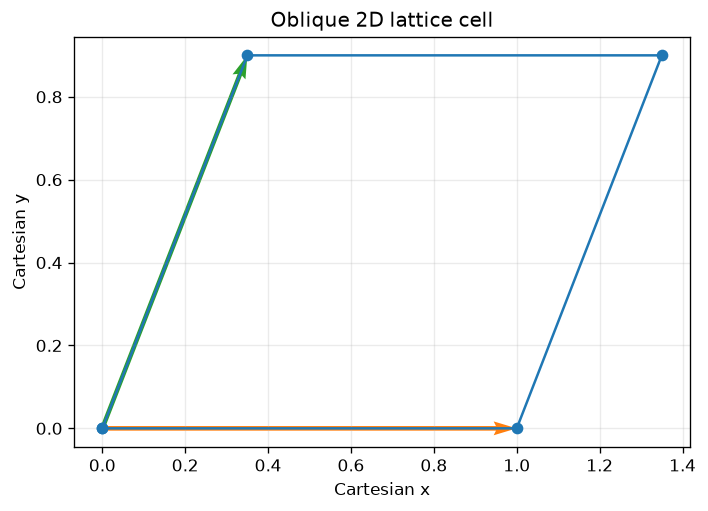

plane-wave Laplacian eigenvalue: -298.76876532680376


In [4]:
mode = np.array([2, -1])
# A fractional plane wave exp(i 2π n·s) has Laplacian eigenvalue below.
eigenvalue = -4 * np.pi**2 * mode @ g_inv @ mode
cartesian_G = B @ mode
assert np.isclose(eigenvalue, -cartesian_G @ cartesian_G, rtol=1e-10, atol=1e-12)
rectangular_lengths = np.array([1.0, 1.4])
rectangular_metric = np.diag(rectangular_lengths**2)
rectangular_value = mode @ np.linalg.inv(rectangular_metric) @ mode
assert np.isclose(rectangular_value, np.sum((mode / rectangular_lengths) ** 2), rtol=1e-10, atol=1e-12)

corners_fractional = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
corners = corners_fractional @ A.T
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(corners[:, 0], corners[:, 1], "o-")
ax.quiver([0, 0], [0, 0], A[0], A[1], angles="xy", scale_units="xy", scale=1, color=["C1", "C2"])
ax.set_aspect("equal")
ax.set(xlabel="Cartesian x", ylabel="Cartesian y", title="Oblique 2D lattice cell")
ax.grid(alpha=0.25)
fig.tight_layout()
show_figure(fig)
plt.close(fig)
print("plane-wave Laplacian eigenvalue:", eigenvalue)


## Interpretation and limitations

Componentwise fractional rounding is not guaranteed to give the nearest image in a skewed cell; the bounded neighbor search makes that limitation visible. The metric is geometric, not material constitutive data.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

MetricTensor3D extends direct/reciprocal geometry and constant-metric operators to a triclinic cell.
